<a href="https://colab.research.google.com/github/JeiGeek/dwi-adc-stroke-segmentacion/blob/main/01_Preprocesamiento_acv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalación de librerías
!pip install -q --upgrade kagglehub nibabel matplotlib

import kagglehub
import os
import nibabel as nib
import matplotlib.pyplot as plt
import random
import numpy as np
import cv2
import zipfile

from skimage.transform import resize
from collections import Counter
from sklearn.model_selection import train_test_split
from google.colab import files

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
# Carga del dataset
path = kagglehub.dataset_download("orvile/isles-2022-brain-stoke-dataset")
print("Los archivos se descargaron en:", path)

100%|██████████| 1.59G/1.59G [01:04<00:00, 26.4MB/s]

Extracting files...


Los archivos se descargaron en: /root/.cache/kagglehub/datasets/orvile/isles-2022-brain-stoke-dataset/versions/1


In [ ]:
#@title **Clasificación de DWI - ADC - MASK** por paciente descartando lo demas
base_path = os.path.join(path, "ISLES-2022", "ISLES-2022")
derivatives_path = os.path.join(base_path, "derivatives")

all_patients = sorted([
    d for d in os.listdir(base_path)
    if d.startswith("sub-strokecase")
])

data_records = []
skipped = []

def get_real_nii_path(folder_path):
    """Si es carpeta .nii, entra y devuelve el archivo real de adentro."""
    if os.path.isdir(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith(".nii") or f.endswith(".nii.gz")]
        if files:
            return os.path.join(folder_path, files[0])
        return None
    elif os.path.isfile(folder_path):
        return folder_path
    return None

for patient in all_patients:
    ses = "ses-0001"
    dwi_dir  = os.path.join(base_path, patient, ses, "dwi")
    mask_dir = os.path.join(derivatives_path, patient, ses)

    if not os.path.exists(dwi_dir) or not os.path.exists(mask_dir):
        skipped.append((patient, "carpeta faltante"))
        continue

    all_files = os.listdir(dwi_dir)

    dwi_folder  = next((f for f in all_files if f.endswith("_dwi.nii")), None)
    adc_folder  = next((f for f in all_files if f.endswith("_adc.nii")), None)

    mask_files  = os.listdir(mask_dir)
    mask_folder = next((f for f in mask_files if "msk" in f and f.endswith(".nii")), None)

    if not dwi_folder:
        skipped.append((patient, "sin DWI")); continue
    if not adc_folder:
        skipped.append((patient, "sin ADC")); continue
    if not mask_folder:
        skipped.append((patient, "sin MASK")); continue

    dwi_real  = get_real_nii_path(os.path.join(dwi_dir, dwi_folder))
    adc_real  = get_real_nii_path(os.path.join(dwi_dir, adc_folder))
    mask_real = get_real_nii_path(os.path.join(mask_dir, mask_folder))

    if not dwi_real or not adc_real or not mask_real:
        skipped.append((patient, "archivo real no encontrado dentro de carpeta"))
        continue

    data_records.append({
        "patient": patient,
        "dwi":  dwi_real,
        "adc":  adc_real,
        "mask": mask_real,
    })

print(f"Pacientes listos: {len(data_records)}")
print(f"Descartados: {len(skipped)}")
for p, r in skipped:
    print(f"  {p} → {r}")

# Verificar uno de ejemplo
print(f"\nEjemplo rutas reales del primer paciente:")
print(f"  DWI:  {data_records[0]['dwi']}")
print(f"  ADC:  {data_records[0]['adc']}")
print(f"  MASK: {data_records[0]['mask']}")

Pacientes listos: 250
Descartados: 0

Ejemplo rutas reales del primer paciente:
  DWI:  /root/.cache/kagglehub/datasets/orvile/isles-2022-brain-stoke-dataset/versions/1/ISLES-2022/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii/sub-strokeperf0041_ses-20180528_ornt-2iso_skull-stripped_sequ-307_dwi.nii
  ADC:  /root/.cache/kagglehub/datasets/orvile/isles-2022-brain-stoke-dataset/versions/1/ISLES-2022/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_adc.nii/sub-strokeperf0041_ses-20180528_ornt-2iso_skull-stripped_sequ-306_adc.nii
  MASK: /root/.cache/kagglehub/datasets/orvile/isles-2022-brain-stoke-dataset/versions/1/ISLES-2022/ISLES-2022/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii


<h3>Las imagenes cuentan con su imagen DWI y ADC parte importante para que todas jueguen con las mismas condiciones y evitar errores

In [ ]:
#@title **Revisión de dimensiones de las imagenes**
all_shapes_dwi  = []
all_shapes_adc  = []
all_shapes_mask = []

for i, record in enumerate(data_records):
    dwi_img  = nib.load(record["dwi"])
    adc_img  = nib.load(record["adc"])
    mask_img = nib.load(record["mask"])

    all_shapes_dwi.append(dwi_img.shape)
    all_shapes_adc.append(adc_img.shape)
    all_shapes_mask.append(mask_img.shape)

print("Distribución de shapes DWI:")
for shape, count in Counter(all_shapes_dwi).most_common():
    print(f"  {shape} → {count} pacientes")

print("\nDistribución de shapes ADC:")
for shape, count in Counter(all_shapes_adc).most_common():
    print(f"  {shape} → {count} pacientes")

print("\nDistribución de shapes MASK:")
for shape, count in Counter(all_shapes_mask).most_common():
    print(f"  {shape} → {count} pacientes")

Distribución de shapes DWI:
  (112, 112, 73) → 93 pacientes
  (112, 112, 72) → 92 pacientes
  (128, 128, 25) → 27 pacientes
  (192, 192, 30) → 23 pacientes
  (128, 128, 72) → 2 pacientes
  (256, 256, 73) → 2 pacientes
  (130, 130, 65) → 1 pacientes
  (115, 115, 28) → 1 pacientes
  (115, 115, 75) → 1 pacientes
  (112, 112, 74) → 1 pacientes
  (170, 170, 33) → 1 pacientes
  (115, 115, 70) → 1 pacientes
  (112, 112, 75) → 1 pacientes
  (112, 112, 76) → 1 pacientes
  (128, 128, 27) → 1 pacientes
  (122, 122, 63) → 1 pacientes
  (128, 128, 30) → 1 pacientes

Distribución de shapes ADC:
  (112, 112, 73) → 93 pacientes
  (112, 112, 72) → 92 pacientes
  (128, 128, 25) → 27 pacientes
  (192, 192, 30) → 23 pacientes
  (128, 128, 72) → 2 pacientes
  (256, 256, 73) → 2 pacientes
  (130, 130, 65) → 1 pacientes
  (115, 115, 28) → 1 pacientes
  (115, 115, 75) → 1 pacientes
  (112, 112, 74) → 1 pacientes
  (170, 170, 33) → 1 pacientes
  (115, 115, 70) → 1 pacientes
  (112, 112, 75) → 1 pacientes
  (11

<h3> Para DWI, ADC y MASK se tiene coherencia con las dimensiones por ende se visualiza que todo está correcto

Paciente: sub-strokecase0001
DWI  shape: (112, 112, 73), min=-10.2, max=1881.3
ADC  shape: (112, 112, 73), min=-0.3, max=4.7
MASK shape: (112, 112, 73), valores únicos: [0. 1.]

Slice con más lesión: 44 (de 73 slices)


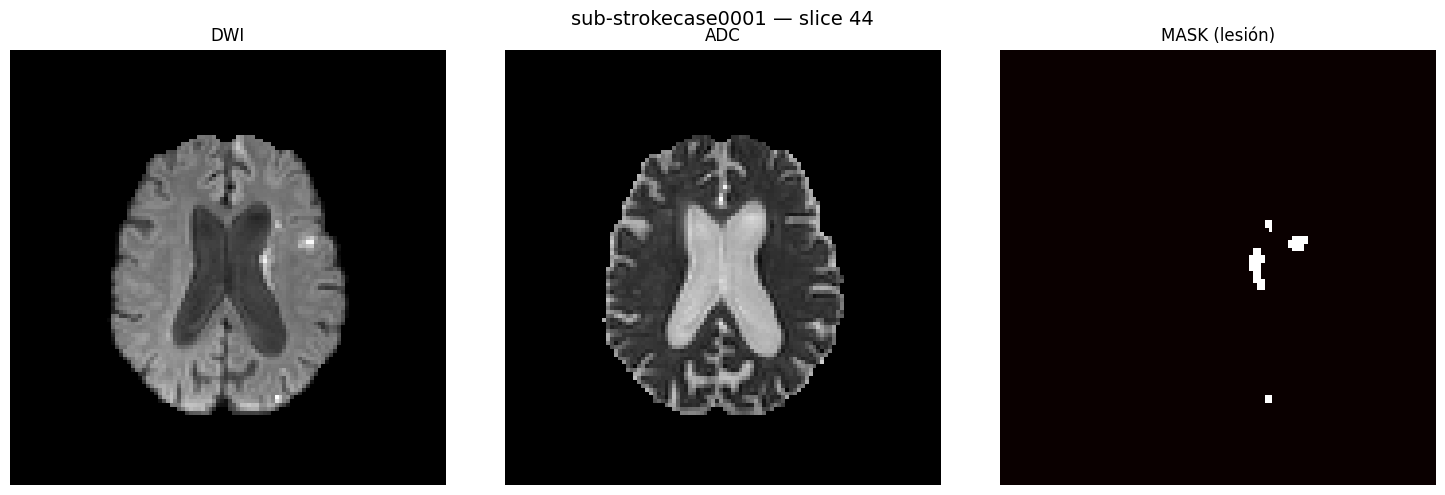

In [ ]:
#@title **Cargar primer paciente**
record = data_records[0]
dwi_vol  = nib.load(record["dwi"]).get_fdata()
adc_vol  = nib.load(record["adc"]).get_fdata()
mask_vol = nib.load(record["mask"]).get_fdata()

print(f"Paciente: {record['patient']}")
print(f"DWI  shape: {dwi_vol.shape}, min={dwi_vol.min():.1f}, max={dwi_vol.max():.1f}")
print(f"ADC  shape: {adc_vol.shape}, min={adc_vol.min():.1f}, max={adc_vol.max():.1f}")
print(f"MASK shape: {mask_vol.shape}, valores únicos: {np.unique(mask_vol)}")

# Encontrar el slice con más lesión
lesion_per_slice = mask_vol.sum(axis=(0,1))
best_slice = int(np.argmax(lesion_per_slice))
print(f"\nSlice con más lesión: {best_slice} (de {mask_vol.shape[2]} slices)")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"{record['patient']} — slice {best_slice}", fontsize=14)

axes[0].imshow(dwi_vol[:, :, best_slice].T, cmap="gray", origin="lower")
axes[0].set_title("DWI")
axes[0].axis("off")

axes[1].imshow(adc_vol[:, :, best_slice].T, cmap="gray", origin="lower")
axes[1].set_title("ADC")
axes[1].axis("off")

axes[2].imshow(mask_vol[:, :, best_slice].T, cmap="hot", origin="lower")
axes[2].set_title("MASK (lesión)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

ANTES — min: -10.2  max: 1881.3  p1: 0.0  p99: 324.4
DESPUÉS — min: 0.000  max: 1.000


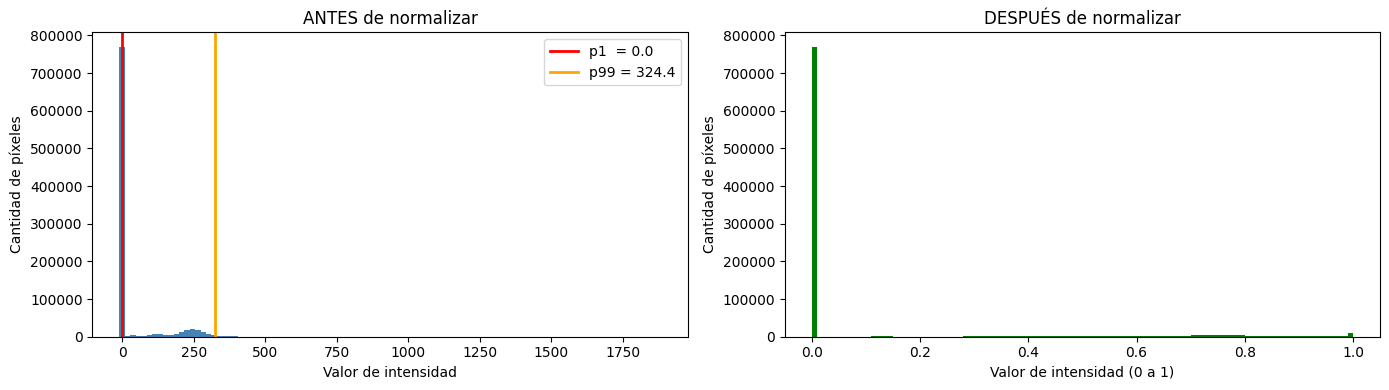

In [ ]:
#@title **Prueba de importancia de normalización por percentiles**
# Cargar un volumen sin normalizar
record = data_records[0]
dwi_raw = nib.load(record["dwi"]).get_fdata()

# Calcular percentiles
p1  = np.percentile(dwi_raw, 1)
p99 = np.percentile(dwi_raw, 99)

# Normalizar
dwi_norm = np.clip(dwi_raw, p1, p99)
dwi_norm = (dwi_norm - p1) / (p99 - p1 + 1e-8)

print(f"ANTES — min: {dwi_raw.min():.1f}  max: {dwi_raw.max():.1f}  p1: {p1:.1f}  p99: {p99:.1f}")
print(f"DESPUÉS — min: {dwi_norm.min():.3f}  max: {dwi_norm.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma ANTES
axes[0].hist(dwi_raw.flatten(), bins=100, color="steelblue")
axes[0].axvline(p1,  color="red",   linewidth=2, label=f"p1  = {p1:.1f}")
axes[0].axvline(p99, color="orange",linewidth=2, label=f"p99 = {p99:.1f}")
axes[0].set_title("ANTES de normalizar")
axes[0].set_xlabel("Valor de intensidad")
axes[0].set_ylabel("Cantidad de píxeles")
axes[0].legend()

# Histograma DESPUÉS
axes[1].hist(dwi_norm.flatten(), bins=100, color="green")
axes[1].set_title("DESPUÉS de normalizar")
axes[1].set_xlabel("Valor de intensidad (0 a 1)")
axes[1].set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

In [ ]:
#@title **Normalización, Redimension y slices 2D**
TARGET_SIZE       = (128, 128)
MIN_LESION_PIXELS = 0
MIN_BRAIN_PIXELS  = int(128 * 128 * 0.10)  # 10%

def normalize(vol):
    """Normalización por percentil para ignorar outliers extremos."""
    p1, p99 = np.percentile(vol, 1), np.percentile(vol, 99)
    vol = np.clip(vol, p1, p99)
    vol = (vol - p1) / (p99 - p1 + 1e-8)
    return vol.astype(np.float32)

def resize_slice(slc):
    """Resize un slice 2D a TARGET_SIZE."""
    return resize(slc, TARGET_SIZE, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

def resize_mask_slice(slc):
    """Resize máscara con interpolación nearest para mantener binaria."""
    return resize(slc, TARGET_SIZE, order=0, preserve_range=True, anti_aliasing=False).astype(np.float32)

# Almacenamiento
all_images = []  # shape por slice: (128, 128, 2)  canal 0 = DWI, canal 1 = ADC
all_masks  = []  # shape por slice: (128, 128)
all_meta   = []  # info del slice para debugging

total_slices         = 0
total_lesion_slices  = 0
total_descartados    = 0

for i, record in enumerate(data_records):
    dwi_vol  = nib.load(record["dwi"]).get_fdata()
    adc_vol  = nib.load(record["adc"]).get_fdata()
    mask_vol = nib.load(record["mask"]).get_fdata()

    # Normalizar volúmenes completos
    dwi_vol = normalize(dwi_vol)
    adc_vol = normalize(adc_vol)

    n_slices = dwi_vol.shape[2]
    total_slices += n_slices

    for s in range(n_slices):

        # Resize primero — todos quedan en 128×128
        dwi_slc  = resize_slice(dwi_vol[:, :, s])
        adc_slc  = resize_slice(adc_vol[:, :, s])
        mask_slc = resize_mask_slice(mask_vol[:, :, s])

        # Filtro 1: suficiente cerebro visible (10% de 128×128)
        if (dwi_slc > 0.05).sum() < MIN_BRAIN_PIXELS:
            total_descartados += 1
            continue

        # Filtro 2: lesión mínima
        if mask_slc.sum() < MIN_LESION_PIXELS:
            continue

        # Apilar DWI y ADC como 2 canales
        img_2ch = np.stack([dwi_slc, adc_slc], axis=-1)  # (128, 128, 2)

        all_images.append(img_2ch)
        all_masks.append(mask_slc)
        all_meta.append({"patient": record["patient"], "slice": s})

        total_lesion_slices += 1

    if (i+1) % 50 == 0:
        print(f"  {i+1}/250 pacientes procesados — slices acumulados: {total_lesion_slices}")

print(f"\nTotal slices en dataset:          {total_slices}")
print(f"Slices descartados (poco cerebro): {total_descartados}")
print(f"Slices extraídos:                 {total_lesion_slices}")
print(f"Shape imagen de muestra:          {all_images[0].shape}")
print(f"Shape máscara de muestra:         {all_masks[0].shape}")
print(f"Rango imagen: [{all_images[0].min():.3f}, {all_images[0].max():.3f}]")
print(f"Valores únicos máscara:           {np.unique(all_masks[0])}")

  50/250 pacientes procesados — slices acumulados: 2512
  100/250 pacientes procesados — slices acumulados: 4993
  150/250 pacientes procesados — slices acumulados: 7492
  200/250 pacientes procesados — slices acumulados: 9215
  250/250 pacientes procesados — slices acumulados: 11001

Total slices en dataset:          15684
Slices descartados (poco cerebro): 4683
Slices extraídos:                 11001
Shape imagen de muestra:          (128, 128, 2)
Shape máscara de muestra:         (128, 128)
Rango imagen: [0.000, 1.000]
Valores únicos máscara:           [0.]


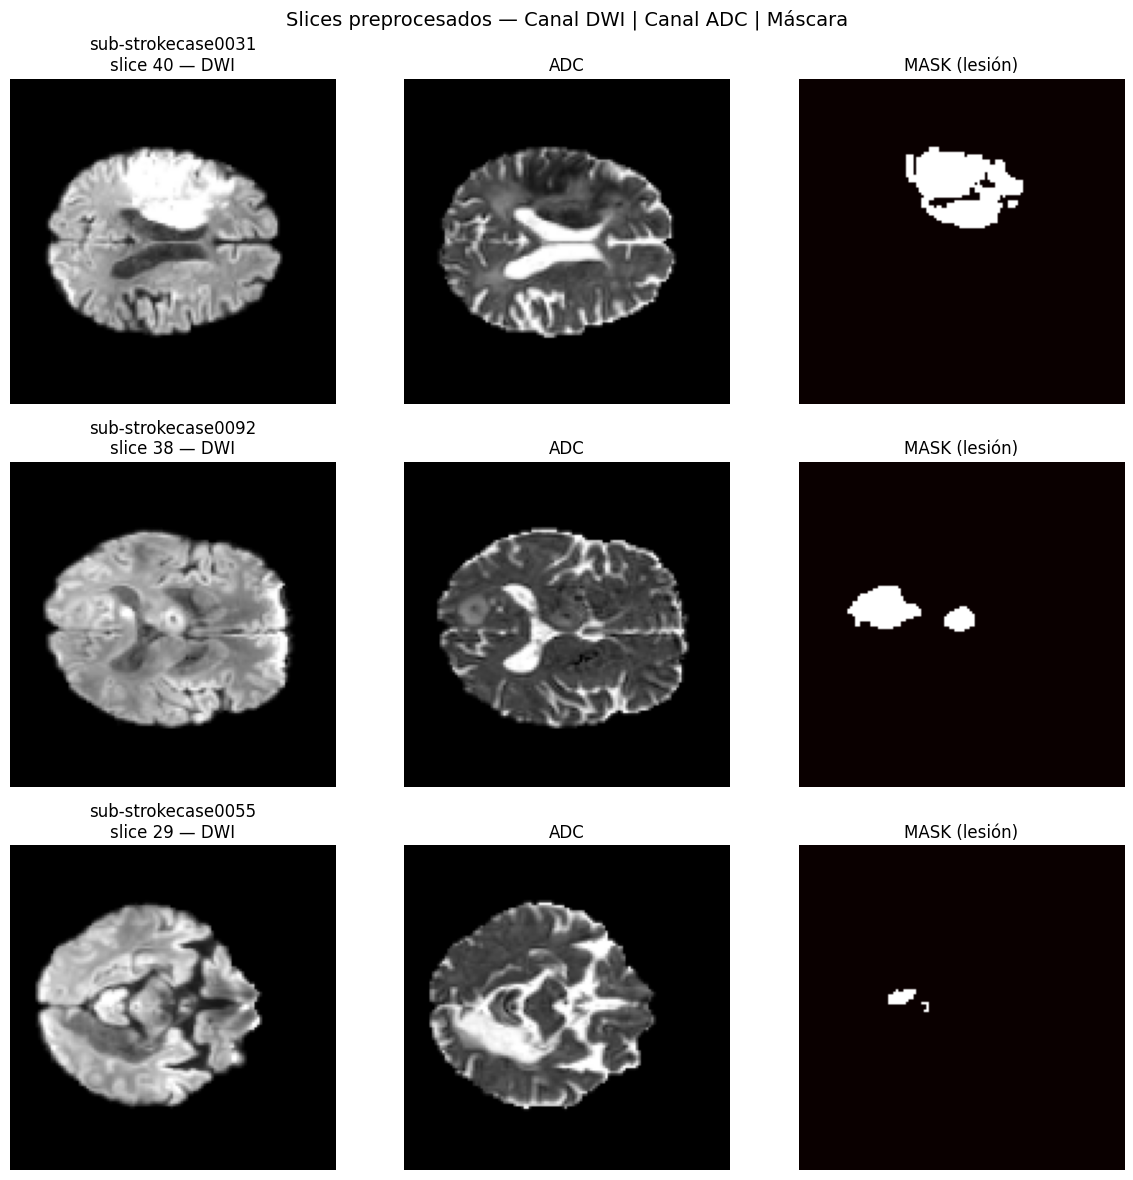

In [ ]:
#@title **Gráfica de slices procesados**

# Elegir 3 slices aleatorios
indices = random.sample(range(len(all_images)), 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Slices preprocesados — Canal DWI | Canal ADC | Máscara", fontsize=14)

for row, idx in enumerate(indices):
    img  = all_images[idx]   # (128, 128, 2)
    mask = all_masks[idx]    # (128, 128)
    meta = all_meta[idx]

    axes[row, 0].imshow(img[:, :, 0], cmap="gray")
    axes[row, 0].set_title(f"{meta['patient']}\nslice {meta['slice']} — DWI")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img[:, :, 1], cmap="gray")
    axes[row, 1].set_title(f"ADC")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(mask, cmap="hot")
    axes[row, 2].set_title(f"MASK (lesión)")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

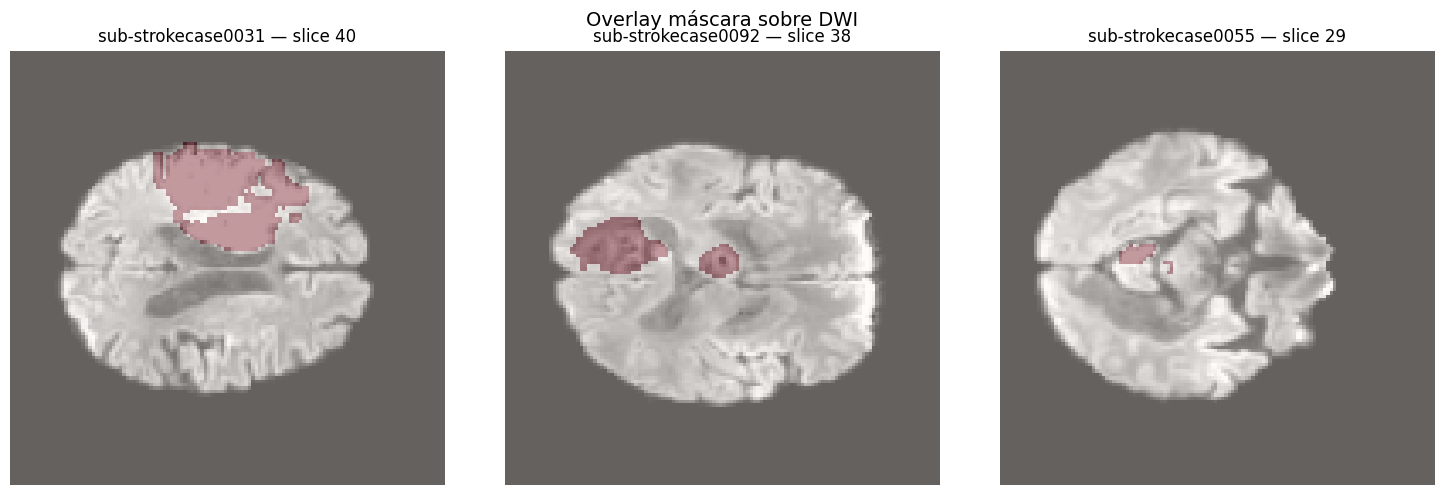

In [ ]:
#@title **Slices con mascara puesta**
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Overlay máscara sobre DWI", fontsize=14)

for col, idx in enumerate(indices):
    img  = all_images[idx]
    mask = all_masks[idx]
    meta = all_meta[idx]

    axes[col].imshow(img[:, :, 0], cmap="gray")
    axes[col].imshow(mask, cmap="Reds", alpha=0.4)
    axes[col].set_title(f"{meta['patient']} — slice {meta['slice']}")
    axes[col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#@title **Convertir listas a arrays numpy**
X = np.array(all_images, dtype=np.float32)  # (3853, 128, 128, 2)
y = np.array(all_masks,  dtype=np.float32)  # (3853, 128, 128)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (11001, 128, 128, 2)
y shape: (11001, 128, 128)


In [ ]:
#@title **Split: 70% train / 15% val / 15% test**

# Crear etiqueta binaria por slice: 1 si tiene lesión, 0 si no
etiqueta = (y.sum(axis=(1,2)) > 0).astype(int)

print(f"Slices CON lesión:    {etiqueta.sum()}")
print(f"Slices SIN lesión:    {(etiqueta == 0).sum()}")
print(f"Total:                {len(etiqueta)}")

# Split estratificado mantiene proporción de lesión en cada split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True, stratify=etiqueta
)

# Etiqueta para el temp también
etiqueta_temp = (y_temp.sum(axis=(1,2)) > 0).astype(int)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=etiqueta_temp
)

# Verificar que los 3 splits tienen lesión
print(f"\n Split estratificado:")
print(f"   Train: {X_train.shape[0]} slices con lesión: {(y_train.sum(axis=(1,2)) > 0).sum()}")
print(f"   Val:   {X_val.shape[0]} slices con lesión: {(y_val.sum(axis=(1,2)) > 0).sum()}")
print(f"   Test:  {X_test.shape[0]} slices con lesión: {(y_test.sum(axis=(1,2)) > 0).sum()}")

Slices CON lesión:    4450
Slices SIN lesión:    6551
Total:                11001

 Split estratificado:
   Train: 7700 slices con lesión: 3115
   Val:   1650 slices con lesión: 667
   Test:  1651 slices con lesión: 668


In [ ]:
#@title **Guardar en disco**
save_dir = "/content/stroke_preprocessed"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "X_val.npy"),   X_val)
np.save(os.path.join(save_dir, "X_test.npy"),  X_test)
np.save(os.path.join(save_dir, "y_train.npy"), y_train)
np.save(os.path.join(save_dir, "y_val.npy"),   y_val)
np.save(os.path.join(save_dir, "y_test.npy"),  y_test)

In [ ]:
#@title **Generar zip de archivos**
save_dir = "/content/stroke_preprocessed"
zip_path = "/content/stroke_preprocessed.zip"

# Crear zip con todos los archivos
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for f in sorted(os.listdir(save_dir)):
        filepath = os.path.join(save_dir, f)
        zipf.write(filepath, arcname=f)
        print(f"  Agregado: {f}")

size_mb = os.path.getsize(zip_path) / 1e6
print(f"\nZIP creado: {size_mb:.1f} MB")
files.download(zip_path)

  Agregado: X_test.npy
  Agregado: X_train.npy
  Agregado: X_val.npy
  Agregado: y_test.npy
  Agregado: y_train.npy
  Agregado: y_val.npy

ZIP creado: 332.7 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>